# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** [Rapika Dahlan]
- **Email:** [cdcc220d6x1867@student.devacademy.id]
- **ID Dicoding:** [CDCC220D6X1867]

## Menentukan Pertanyaan Bisnis

- Pertanyaan 1: Pada jam berapa penyewaan sepeda paling tinggi dan paling rendah?
- Pertanyaan 2: Bagaimana pola penggunaan sepeda antara hari kerja dan hari libur?

## Import Semua Packages/Library yang Digunakan

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Data Wrangling

### Gathering Data

In [25]:
hour_df = pd.read_csv('data/hour.csv')
day_df = pd.read_csv('data/day.csv')

hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


**Insight:**
- Dataset terdiri dari data penyewaan sepeda per jam yang mencakup berbagai fitur seperti waktu (jam, tanggal), kondisi cuaca, suhu, dan jumlah penyewaan.
- Variabel target utama adalah `cnt`, yang menunjukkan total jumlah sepeda yang disewa dalam satu jam.
- Dataset juga membedakan antara pengguna casual dan registered, sehingga memungkinkan analisis perilaku pengguna lebih lanjut.
- Tidak terlihat adanya missing values pada tampilan awal data, sehingga data relatif bersih untuk dianalisis lebih lanjut.

### Assessing Data

In [26]:
hour_df.info()
hour_df.isnull().sum()
hour_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


np.int64(0)

**Insight:**
- Dataset terdiri dari 17.379 baris dan 17 kolom yang mencakup informasi waktu, cuaca, dan jumlah penyewaan sepeda.
- Tidak ditemukan missing values pada seluruh kolom, sehingga data dapat langsung digunakan untuk analisis tanpa penanganan nilai kosong.
- Tidak terdapat data duplikat dalam dataset, sehingga kualitas data cukup baik.
- Terdapat beberapa tipe data yang perlu diperhatikan, seperti kolom `dteday` yang masih bertipe object dan sebaiknya diubah menjadi datetime untuk analisis lebih lanjut.

### Cleaning Data

In [27]:
# Ubah tipe data
hour_df['dteday'] = pd.to_datetime(hour_df['dteday'])

# Mapping cuaca
weather_map = {
    1: 'Cerah',
    2: 'Berawan',
    3: 'Hujan Ringan',
    4: 'Hujan Lebat'
}
hour_df['weather_label'] = hour_df['weathersit'].map(weather_map)

hour_df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,weather_label
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,Cerah
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,Cerah
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,Cerah
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,Cerah
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,Cerah


**Insight:**
- Kolom `dteday` berhasil dikonversi dari tipe object menjadi datetime agar memudahkan analisis berbasis waktu.
- Dilakukan mapping pada kolom `weathersit` menjadi `weather_label` agar lebih mudah dipahami (misalnya: Cerah, Berawan, Hujan).
- Penambahan kolom `weather_label` membantu dalam proses visualisasi dan interpretasi data.
- Secara keseluruhan, data telah dibersihkan dan siap digunakan untuk tahap analisis lebih lanjut.

## Exploratory Data Analysis (EDA)

### Explore ...

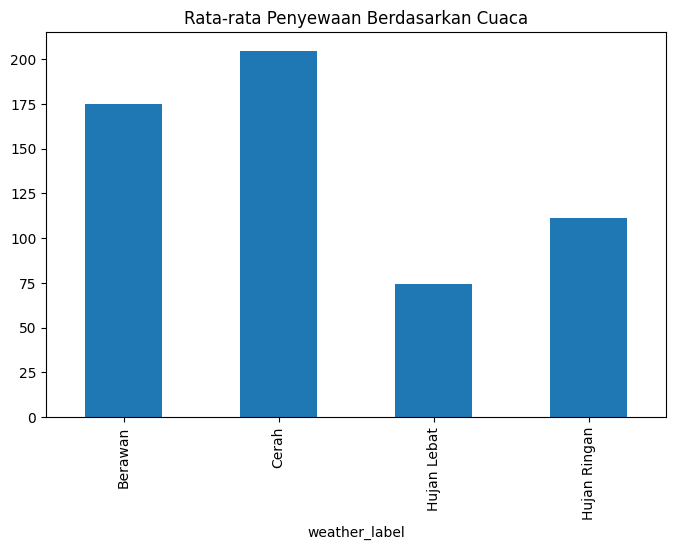

In [28]:
weather_analysis = hour_df.groupby('weather_label')['cnt'].mean()

plt.figure(figsize=(8,5))
weather_analysis.plot(kind='bar')
plt.title('Rata-rata Penyewaan Berdasarkan Cuaca')
plt.show()

**Insight:**
- Penyewaan sepeda tertinggi terjadi pada kondisi cuaca cerah, menunjukkan bahwa pengguna lebih nyaman bersepeda saat cuaca baik.
- Cuaca berawan masih memiliki tingkat penyewaan yang cukup tinggi, meskipun sedikit di bawah cuaca cerah.
- Penyewaan menurun cukup signifikan pada kondisi hujan ringan, dan paling rendah saat hujan lebat.
- Hal ini menunjukkan bahwa kondisi cuaca memiliki pengaruh besar terhadap keputusan pengguna dalam menyewa sepeda.

## Visualization & Explanatory Analysis

### Pertanyaan 1:

In [29]:
# Analisis rata-rata penyewaan per jam
hour_analysis = hour_df.groupby('hr')['cnt'].mean().sort_values(ascending=False)

hour_analysis.head()

,cnt
hr,
17,461.452055
18,425.510989
8,359.011004
16,311.983562
19,311.523352


Visualisasi 1:

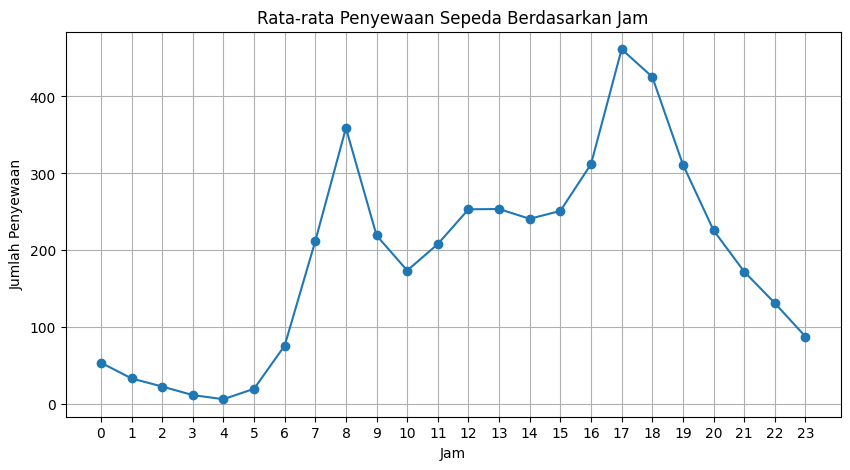

In [30]:
plt.figure(figsize=(10,5))
hour_df.groupby('hr')['cnt'].mean().plot(kind='line', marker='o')
plt.title('Rata-rata Penyewaan Sepeda Berdasarkan Jam')
plt.xlabel('Jam')
plt.ylabel('Jumlah Penyewaan')
plt.xticks(range(0,24))
plt.grid()
plt.show()

**Insight:**
- Penyewaan sepeda mencapai puncaknya pada jam 08.00 serta 17.00–18.00, yang merupakan waktu berangkat dan pulang kerja.
- Hal ini menunjukkan bahwa sepeda banyak digunakan sebagai sarana transportasi harian (commuter).
- Jumlah penyewaan mulai meningkat sejak pagi hari (sekitar jam 06.00) dan kembali meningkat pada sore hari.
- Penyewaan terendah terjadi pada dini hari (00.00–05.00), ketika aktivitas masyarakat masih rendah.
- Setelah jam 19.00, jumlah penyewaan kembali menurun secara bertahap.

### Pertanyaan 2:

In [31]:
# Analisis berdasarkan hari kerja
workingday_analysis = hour_df.groupby('workingday')['cnt'].mean()

workingday_analysis

,cnt
workingday,
0,181.405332
1,193.207754


Visualisasi 2:

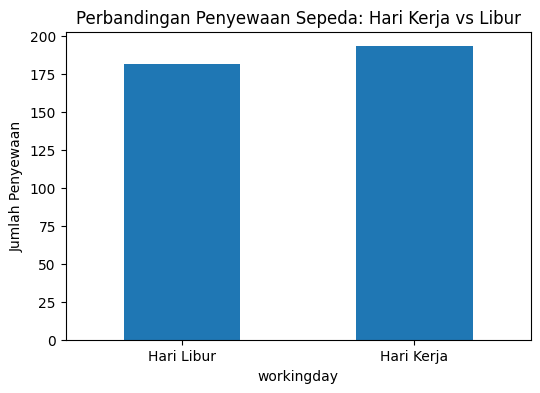

In [32]:
plt.figure(figsize=(6,4))
workingday_analysis.plot(kind='bar')
plt.xticks([0,1], ['Hari Libur', 'Hari Kerja'], rotation=0)
plt.title('Perbandingan Penyewaan Sepeda: Hari Kerja vs Libur')
plt.ylabel('Jumlah Penyewaan')
plt.show()

**Insight:**
- Penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur.
- Hal ini menunjukkan bahwa sepeda lebih banyak digunakan sebagai sarana transportasi rutin, seperti pergi bekerja atau sekolah.
- Meskipun pada hari libur masih terdapat aktivitas penyewaan, jumlahnya cenderung lebih rendah karena penggunaan lebih bersifat rekreasi.
- Perbedaan ini menunjukkan adanya pola penggunaan sepeda yang dipengaruhi oleh aktivitas harian masyarakat.

## Analisis Lanjutan (Opsional)

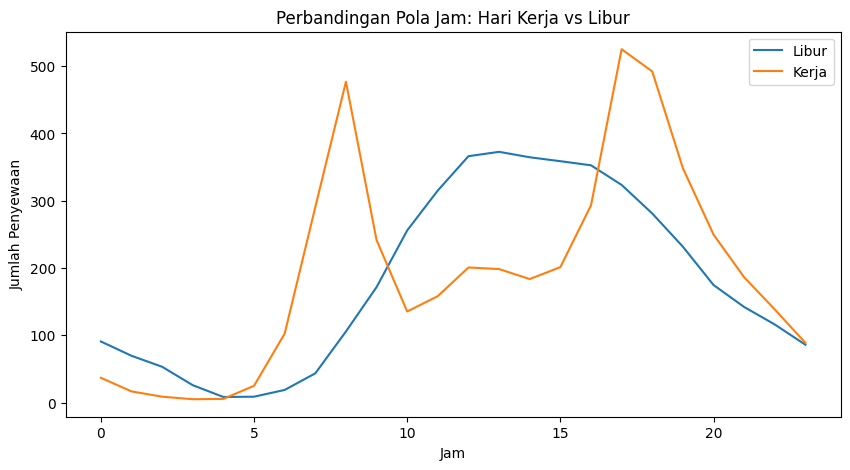

In [33]:
# Bandingkan jam sibuk antara hari kerja dan libur
pivot_data = hour_df.pivot_table(values='cnt', index='hr', columns='workingday', aggfunc='mean')

pivot_data.plot(figsize=(10,5))
plt.title('Perbandingan Pola Jam: Hari Kerja vs Libur')
plt.xlabel('Jam')
plt.ylabel('Jumlah Penyewaan')
plt.legend(['Libur', 'Kerja'])
plt.show()

## Conclusion


**Pertanyaan 1: Pada jam berapa penyewaan sepeda paling tinggi dan paling rendah?**
- Penyewaan sepeda menunjukkan pola harian yang jelas, dengan puncak terjadi pada pagi hari (sekitar pukul 08.00) dan sore hari (sekitar pukul 17.00–18.00).
- Pola ini mengindikasikan bahwa sepeda banyak digunakan sebagai sarana transportasi untuk aktivitas kerja (commuter).
- Penyewaan terendah terjadi pada dini hari (00.00–05.00), ketika aktivitas masyarakat masih rendah.

**Pertanyaan 2: Bagaimana perbedaan penyewaan antara hari kerja dan hari libur?**
- Penyewaan sepeda pada hari kerja lebih tinggi dibandingkan hari libur.
- Pada hari kerja terlihat dua puncak penggunaan (pagi dan sore), sedangkan pada hari libur pola penggunaan lebih merata tanpa lonjakan signifikan.
- Hal ini menunjukkan bahwa penggunaan sepeda pada hari kerja lebih bersifat rutin (transportasi), sedangkan pada hari libur lebih bersifat rekreasi.

In [34]:
import os

os.makedirs('dashboard', exist_ok=True)

In [35]:
df = hour_df[['hr', 'workingday', 'cnt']]
df.to_csv('dashboard/main_data.csv', index=False)

In [36]:
dashboard_code = """
import streamlit as st
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('main_data.csv')

st.title('Dashboard Bike Sharing 🚲')

# Filter
hour_range = st.slider('Pilih Jam', 0, 23, (0, 23))

filtered_df = df[(df['hr'] >= hour_range[0]) & (df['hr'] <= hour_range[1])]

# Grafik jam
st.subheader('Penyewaan per Jam')
hour_data = filtered_df.groupby('hr')['cnt'].mean()

fig, ax = plt.subplots()
hour_data.plot(ax=ax)
st.pyplot(fig)

# Grafik hari
st.subheader('Hari Kerja vs Libur')
day_data = filtered_df.groupby('workingday')['cnt'].mean()

fig2, ax2 = plt.subplots()
day_data.plot(kind='bar', ax=ax2)
ax2.set_xticklabels(['Libur', 'Kerja'], rotation=0)
st.pyplot(fig2)
"""

with open('dashboard/dashboard.py', 'w') as f:
    f.write(dashboard_code)

In [37]:
!ls

dashboard  README.md	     sample_data     url.txt
data	   requirements.txt  submission.zip
